<a href="https://colab.research.google.com/github/KarthikSaravanakumarM56/24ADI003-24BAD056/blob/main/Scenario5_SMOTE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Scenario 5 - SMOTE for Class Imbalance
### Detecting Fraudulent Transactions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, precision_recall_curve, average_precision_score
from imblearn.over_sampling import SMOTE

In [2]:
df = pd.read_csv("fraud_smote.csv")
print(df.shape)
df.head()

(120, 5)


,Amount,Time,Feature1,Feature2,Fraud
0,3233.38,34595,2.157308,-0.818199,0
1,2783.63,73166,1.561511,0.955305,0
2,923.74,84417,-0.027305,-1.418366,0
3,2214.14,11139,-0.643518,-0.466037,0
4,444.75,37847,0.021272,-0.529053,0


In [3]:
# Check class distribution before SMOTE
print("Class Distribution Before SMOTE:")
print(df["Fraud"].value_counts())

Class Distribution Before SMOTE:
Fraud
0    110
1     10
Name: count, dtype: int64


In [4]:
X = df.drop("Fraud", axis=1)
y = df["Fraud"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# Train Logistic Regression BEFORE SMOTE
lr_before = LogisticRegression(max_iter=1000, random_state=42)
lr_before.fit(X_train, y_train)
y_pred_before = lr_before.predict(X_test)
print("Before SMOTE:")
print(classification_report(y_test, y_pred_before, target_names=["Normal (0)", "Fraud (1)"]))

Before SMOTE:
              precision    recall  f1-score   support

  Normal (0)       0.92      1.00      0.96        22
   Fraud (1)       0.00      0.00      0.00         2

    accuracy                           0.92        24
   macro avg       0.46      0.50      0.48        24
weighted avg       0.84      0.92      0.88        24



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [6]:
# Apply SMOTE on training data
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f"After SMOTE - Class distribution: {pd.Series(y_train_sm).value_counts().to_dict()}")

After SMOTE - Class distribution: {0: 88, 1: 88}


In [7]:
# Train Logistic Regression AFTER SMOTE
lr_after = LogisticRegression(max_iter=1000, random_state=42)
lr_after.fit(X_train_sm, y_train_sm)
y_pred_after = lr_after.predict(X_test)
print("After SMOTE:")
print(classification_report(y_test, y_pred_after, target_names=["Normal (0)", "Fraud (1)"]))

After SMOTE:
              precision    recall  f1-score   support

  Normal (0)       1.00      0.36      0.53        22
   Fraud (1)       0.12      1.00      0.22         2

    accuracy                           0.42        24
   macro avg       0.56      0.68      0.38        24
weighted avg       0.93      0.42      0.51        24



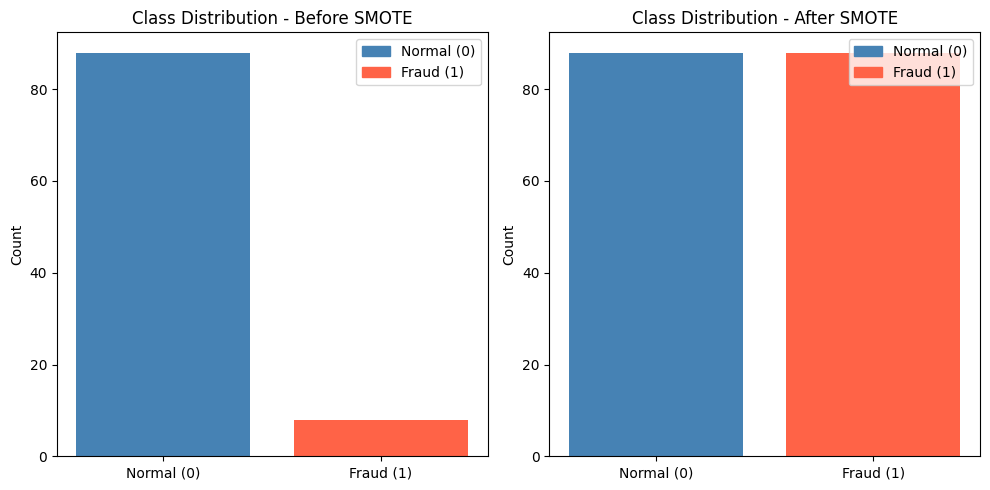

In [8]:
# Class Distribution - Before & After SMOTE
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

before_counts = y_train.value_counts()
after_counts = pd.Series(y_train_sm).value_counts()

colors = ["steelblue", "tomato"]
labels = ["Normal (0)", "Fraud (1)"]

axes[0].bar(labels, [before_counts.get(0, 0), before_counts.get(1, 0)], color=colors)
axes[0].set_title("Class Distribution - Before SMOTE")
axes[0].set_ylabel("Count")
import matplotlib.patches as mpatches
legend_p = [mpatches.Patch(color=c, label=l) for c, l in zip(colors, labels)]
axes[0].legend(handles=legend_p)

axes[1].bar(labels, [after_counts.get(0, 0), after_counts.get(1, 0)], color=colors)
axes[1].set_title("Class Distribution - After SMOTE")
axes[1].set_ylabel("Count")
axes[1].legend(handles=legend_p)

plt.tight_layout()
plt.savefig("scenario5_distribution.png", dpi=100)
plt.show()

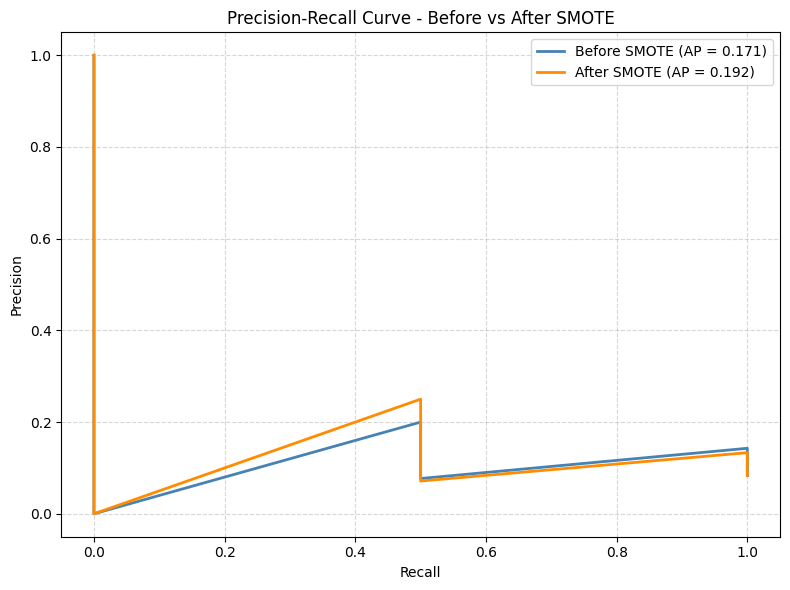

In [9]:
# Precision-Recall Curve - Before and After SMOTE
prob_before = lr_before.predict_proba(X_test)[:, 1]
prob_after = lr_after.predict_proba(X_test)[:, 1]

prec_b, rec_b, _ = precision_recall_curve(y_test, prob_before)
prec_a, rec_a, _ = precision_recall_curve(y_test, prob_after)

ap_before = average_precision_score(y_test, prob_before)
ap_after = average_precision_score(y_test, prob_after)

plt.figure(figsize=(8, 6))
plt.plot(rec_b, prec_b, color="steelblue", lw=2, label=f"Before SMOTE (AP = {ap_before:.3f})")
plt.plot(rec_a, prec_a, color="darkorange", lw=2, label=f"After SMOTE (AP = {ap_after:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Before vs After SMOTE")
plt.legend(loc="upper right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("scenario5_pr_curve.png", dpi=100)
plt.show()